# Imports

In [1]:
%matplotlib inline

In [2]:
import importlib

import datetime
import json
import os

import pandas as pd

import tagbiopy.utils
import tagbiopy.plots
import tagbiopy.regression.elastic_net

# Dev: reload tagbiopy 

In [3]:
importlib.reload(tagbiopy.utils)

<module 'tagbiopy.utils' from '/Users/damir/code/tagbiopy/tagbiopy/utils.py'>

In [4]:
importlib.reload(tagbiopy.plots)

<module 'tagbiopy.plots' from '/Users/damir/code/tagbiopy/tagbiopy/plots.py'>

In [5]:
importlib.reload(tagbiopy.regression.elastic_net)

<module 'tagbiopy.regression.elastic_net' from '/Users/damir/code/tagbiopy/tagbiopy/regression/elastic_net.py'>

# Aux function to mimic the CLE

In [6]:
def connect_tagbio_py(fc_packet, user_function, output_file=None, extension='jpg'):
    cli = '$HOME/code/tagbiopy/tagbiopy/bin/connect_tagbio_pyenv.sh'
    !{cli} -d {fc_packet} -f {user_function} -o {output_file} -t {extension}

# Project

### FC packet

In [8]:
fc_packet = './plos_one_51286519160991180803948921709669669310.json'

### User function

In [9]:
py_script = '/Users/damir/code/protocols/customers/pfizer/fc-topaz/python/elastic_net_cross_validation.py'

### Extension

In [10]:
extension = 'html'

### Output file

In [11]:
output_file_from_cli = '_cli_result' + tagbiopy.utils.now('_') + '.' + extension

# Mimic the run from within the fc

In [12]:
%%time

connect_tagbio_py(fc_packet, py_script, output_file_from_cli, extension)

Python log file: /var/folders/n4/p8bky4cs7rsgdn15v61ys0lc0000gn/T/tagbio_py_2020-04-13_22-49-20_gm_m6dnn.log
2020-04-13 22-49-20: Python command line arguments:
{
  "fc_data": "./plos_one_51286519160991180803948921709669669310.json",
  "user_function": "/Users/damir/code/protocols/customers/pfizer/fc-topaz/python/elastic_net_cross_validation.py",
  "output_type": "html",
  "output_file": "_cli_result2020-04-13_22-49-09.html"
}
/Users/damir/.pyenv/versions/3.8.0/envs/fc/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:474: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.108224377892932e-06, tolerance: 1.3359192747059114e-06
  model = cd_fast.enet_coordinate_descent(
/Users/damir/.pyenv/versions/3.8.0/envs/fc/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:474: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2

# Scatter plot with plotly

In [3]:
in_file = './elastic_net_results_2020-04-13_22-56-52_8yvcncf4.txt'
df = pd.read_csv(in_file, sep='\t', index_col='patient_id')
y = df.iloc[:,0]
y_hat = df.iloc[:,1]

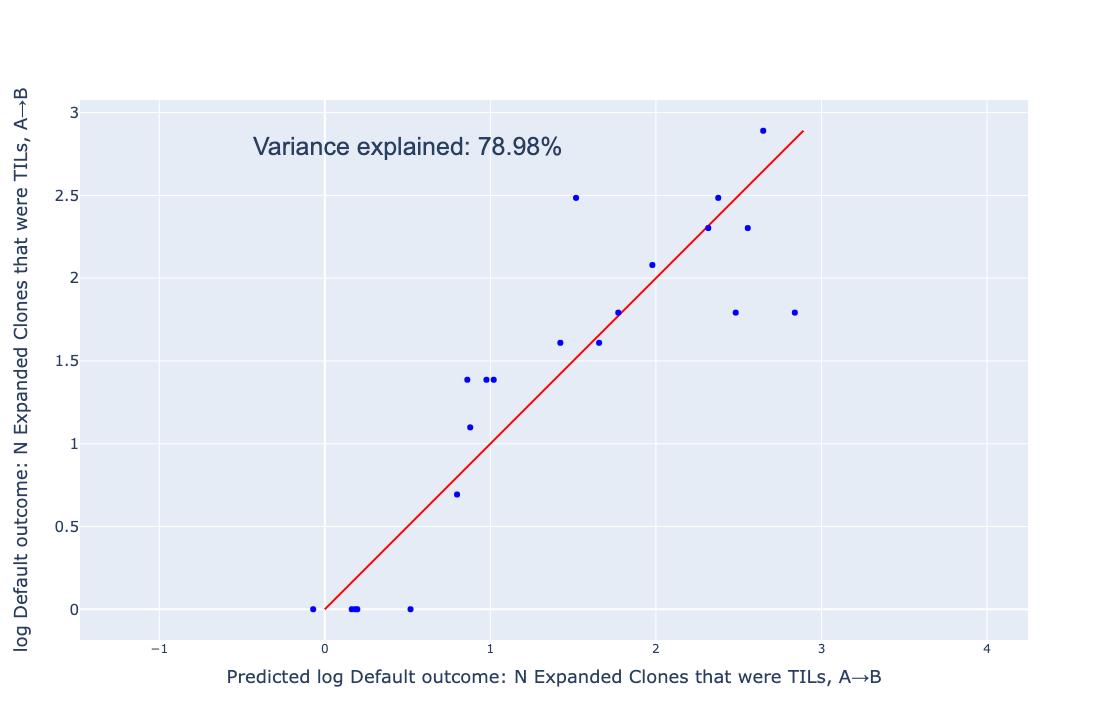

In [12]:
importlib.reload(tagbiopy.plots)
fig = tagbiopy.plots.r2_plotly(y_hat, y)
fig.show()

# Run from the notebook

### User function

In [17]:
user_function = tagbiopy.utils.load_function(py_script)

### Output file

In [18]:
output_file_from_ipy = 'tag_result_jupyter_' + tagbiopy.utils.now('_') + '.' + extension

## tag_data: tagbiopy.utils.TagbioData

In [19]:
tag_data = tagbiopy.utils.TagbioData(fc_packet=fc_packet)
tag_data.entity_id = 'patient_id'
outcome_column = tag_data.fc_packet.passthrough_arguments['model_outcome_variable'][0]

In [20]:
tag_data.df

,"log Default outcome: N Expanded Clones that were TILs, A->B",Plos One: Age,Plos One: Albumin < 4,Plos One: Baseline neutrophil to lymphocyte ratio,Plos One: Clonality,Plos One: Clonality_tumor,Plos One: Diversity,Plos One: Diversity_tumor,Plos One: Number of chemo regimens total,Plos One: Prior BCG,...,Plos One: log_T-cell fraction_tumor,Plos One: log_Time since last chemotherapy,Plos One: log_Top Clone Freq(%),Plos One: log_expressed_missense_snv_count,Plos One: log_expressed_neoantigen_count,Plos One: log_factor score,Plos One: log_missense_snv_count,Plos One: log_neoantigen_count,Plos One: missense_snv_count,Plos One: neoantigen_count
patient_id,,,,,,,,,,,,,,,,,,,,,
40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,2.079442,68.0,0.0,4.25,0.348957,0.115946,10.497178,8.408900,1.0,0.0,...,0.064476,6.033086,2.789133,4.394449,5.062595,0.693147,5.293305,6.272877,198.0,529.0
522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1233,2.484907,66.0,0.0,4.22,0.047118,0.128326,16.449041,10.373350,2.0,0.0,...,0.196471,4.369448,0.660163,0.000000,0.000000,1.386294,1.098612,1.609438,2.0,4.0
1249,1.791759,78.0,0.0,1.53,0.219364,0.221381,13.171150,7.624849,1.0,0.0,...,0.035657,3.295837,2.518287,2.079442,2.944439,1.609438,5.389072,6.381816,218.0,590.0
1849,1.386294,69.0,1.0,6.67,0.157365,0.339484,14.188557,7.638306,3.0,0.0,...,0.205631,5.755742,2.248386,3.737670,4.219508,1.386294,5.198497,5.472271,180.0,237.0
1994,0.000000,81.0,0.0,7.40,0.021941,0.093285,16.771246,9.265869,2.0,0.0,...,0.107149,5.863631,0.213136,1.098612,1.386294,0.693147,1.386294,1.945910,3.0,6.0
2131,2.302585,61.0,0.0,1.68,0.027297,0.110512,16.794043,8.598776,1.0,0.0,...,0.183071,4.595120,0.305008,5.220356,5.332719,0.693147,6.023448,6.340359,412.0,566.0
2278,1.386294,62.0,0.0,2.71,0.208770,0.046536,13.548723,8.848881,1.0,0.0,...,0.047456,5.855072,1.187460,2.079442,0.693147,0.693147,2.708050,1.098612,14.0,2.0


In [21]:
y_fc, X_fc = tagbiopy.regression.elastic_net.set_outcome_and_observations(tag_data.df, outcome_column)

In [23]:
X_fc['Plos One: Time since last chemotherapy']

patient_id
471     416.0
1233     78.0
1249     26.0
1849    315.0
1994    351.0
2131     98.0
2278    348.0
2389      NaN
2849    317.0
2937     77.0
3529    960.0
5037     70.0
5122    149.0
5338    626.0
6229    182.0
6428     63.0
7577    130.0
7729    130.0
8728    617.0
9517    280.0
9881     54.0
Name: Plos One: Time since last chemotherapy, dtype: float64

# Compare input data against Plos One data

In [ ]:
project_name = 'topaz'
customer = 'pfizer'


DATA_BASE_DIR = '/Users/damir/data/{}-data'.format(project_name)
PROCESSED_DATA_DIR = os.path.join(DATA_BASE_DIR, 'processed')

FEATURES_FILE = os.path.join(PROCESSED_DATA_DIR, 'snyder_et_al_processed_data-features.tsv')
OUTCOMES_FILE = os.path.join(PROCESSED_DATA_DIR, 'snyder_et_al_processed_data-outcomes.tsv')

In [ ]:
y_plos_one = pd.read_csv(OUTCOMES_FILE, index_col=0, sep='\t', squeeze=True)
X_plos_one = pd.read_csv(FEATURES_FILE, index_col=0, sep='\t')

X_plos_one = X_plos_one[sorted(X_plos_one.columns)]

In [ ]:
X = X[sorted(X.columns)]

## Outcome variables

Outcome variables are the same if their difference is less than eps, some small value

In [ ]:
eps = 1e-16

In [ ]:
s = 'Outcome variable in Plos One and in Tag.bio FC are '
if (y_fc - y_plos_one).sum() > eps:
    s += 'not '
s += 'equal.'

In [ ]:
print(s)

## Predictors

In [ ]:
X_fc.columns = [v.replace('Plos One: ', '') for v in X_fc.columns]
X_fc = X_fc[sorted(X_fc.columns)]

In [ ]:
s = 'Predictors in Plos One and in Tag.bio FC are '

if (X - X_fc).sum().sum() > eps:
    s += 'not '
s += 'equal.'

In [ ]:
print(s)

## tag_result: tagbio.utils.TagbioResult

In [ ]:
tag_result = tagbiopy.utils.TagbioResult(extension=extension, 
                                         path=output_file_from_ipy, 
                                         path_mutable=False)

## Execute user function

In [ ]:
%%time

user_function(tag_data, tag_result)

In [ ]:
tag_result.fig

In [ ]:
X[sorted(X.columns)]

In [ ]:
tag_data.df[tag_data.df.index == 471].T

In [ ]:
tag_data.fc_packet.r.content

In [ ]:
tag_data.df['Plos One: Prior BCG']

In [ ]:
import plotly.graph_objects

In [ ]:
isinstance(fig, plotly.graph_objs.Figure)

In [ ]:
tag_data = tagbiopy.utils.TagbioData(fc_packet)
tag_data.entity_id = 'patient_id'

In [ ]:
tag_data

In [ ]:
extension = 'pdf'
fig_path = 'test_' + tagbiopy.utils.now().replace(' ', '-') + '.' + extension
tag_result = tagbiopy.utils.TagbioResult(extension=extension, path=fig_path, path_mutable=False)
tag_result.fh = open('from_notebook_{}.log'.format(tagbiopy.utils.now().replace(' ', '-')), 'w')

In [ ]:
%%time

tag_result = user_function(tag_data, tag_result)

In [ ]:
tag_result.fig

In [ ]:
tag_result.save()

# Plos One data

In [ ]:
project_name = 'topaz'
customer = 'pfizer'

DATA_BASE_DIR = '/Users/damir/data/{}-data'.format(project_name)
SOURCE_DATA_DIR = os.path.join(DATA_BASE_DIR, 'source_data')
PROCESSED_DATA_DIR = os.path.join(DATA_BASE_DIR, 'processed')
MODELS_DATA = os.path.join(DATA_BASE_DIR, 'models')

FEATURES_FILE = os.path.join(PROCESSED_DATA_DIR, 'snyder_et_al_processed_data-features.tsv')
FEATURE_CLASSES_FILE = os.path.join(PROCESSED_DATA_DIR, 'snyder_et_al_processed_data-feature-classes.tsv')
OUTCOMES_FILE = os.path.join(PROCESSED_DATA_DIR, 'snyder_et_al_processed_data-outcomes.tsv')

FEATURE_CLASSES = pd.read_csv(FEATURE_CLASSES_FILE, sep='\t').Class.value_counts().index.to_list()

In [ ]:
X = pd.read_csv(FEATURES_FILE, index_col=0, sep='\t')
y = pd.read_csv(OUTCOMES_FILE, index_col=0, sep='\t', squeeze=True)
feature_classes = pd.read_csv(FEATURE_CLASSES_FILE, index_col=0, sep='\t')

outcome_name = y.name
patients = X.index

In [ ]:
X.shape

In [ ]:
%%time
y_hat_tag, tag_model_params = \
    tagbiopy.regression.elastic_net.elastic_net_cross_validation(y, X)

In [ ]:
fig_tb = tagbiopy.plots.r2_plot(y, y_hat_tag, title='tagbiopy.regression.elastic_net: Plos One data')

In [ ]:
fig_tb

# Check differences b/w Plos One and FC data

In [ ]:
plos_one_to_tag_columns = {
    'Age': 'Model input: Age', 
    'Albumin < 4': 'Model input: Albumin < 4', 
    'Baseline neutrophil to lymphocyte ratio': 'Model input: Baseline neutrophil to lymphocyte ratio',
    'Clonality': 'Model input: Clonality: PBMC, Time point A', 
    'Clonality_tumor': 'Model input: Clonality: Tumor, Time point A', 
    'Diversity': 'Model input: Diversity: PBMC, Time point A',
    'Diversity_tumor': 'Model input: Diversity: Tumor, Time point A',
    'Number of chemo regimens total': 'Model input: Number of chemo regimens total',
    'Prior BCG': 'Model input: Prior BCG',
    'Productive Unique TCRs (cnt)': 'Model input: Productive Unique TCRs (cnt): PBMC, Time point A',
    'T-cell fraction': 'Model input: T-cell fraction: PBMC, Time point A',
    'T-cell fraction_tumor': 'Model input: T-cell fraction: Tumor, Time point A', 
    'Time since last chemotherapy': 'Model input: Time since last chemotherapy',
    'Top Clone Freq(%)': 'Model input: Top Clone Freq(%): PBMC, Time point A', 
    'expressed_missense_snv_count': 'Model input: expressed_missense_snv_count',
    'expressed_neoantigen_count': 'Model input: expressed_neoantigen_count', 
    'factor score': 'Model input: 5-factor score', 
    'log_Age': 'Model input: log Age',
    'log_Baseline neutrophil to lymphocyte ratio': 'Model input: log Baseline neutrophil to lymphocyte ratio', 
    'log_Clonality': 'Model input: log Clonality: PBMC, Time point A',
    'log_Clonality_tumor': 'Model input: log Clonality: Tumor, Time point A', 
    'log_Diversity': 'Model input: log Diversity: PBMC, Time point A', 
    'log_Diversity_tumor': 'Model input: log Diversity: Tumor, Time point A',
    'log_Number of chemo regimens total': 'Model input: log Number of chemo regimens total',
    'log_Productive Unique TCRs (cnt)': 'Model input: log Productive Unique TCRs (cnt): PBMC, Time point A', 
    'log_T-cell fraction': 'Model input: log T-cell fraction: PBMC, Time point A',
    'log_T-cell fraction_tumor': 'Model input: log T-cell fraction: Tumor, Time point A', 
    'log_Time since last chemotherapy': 'Model input: log Time since last chemotherapy',
    'log_Top Clone Freq(%)': 'Model input: log Top Clone Freq(%): PBMC, Time point A', 
    'log_expressed_missense_snv_count': 'Model input: log expressed_missense_snv_count',
    'log_expressed_neoantigen_count': 'Model input: log expressed_neoantigen_count', 
    'log_factor score': 'Model input: log 5-factor score',
    'log_missense_snv_count': 'Model input: log missense_snv_count', 
    'log_neoantigen_count': 'Model input: log neoantigen_count', 
    'missense_snv_count': 'Model input: missense_snv_count',
    'neoantigen_count': 'Model input: neoantigen_count'
}

In [ ]:
def concat_columns(s1, s2):
    return pd.concat([s1, s2], axis=1)

In [ ]:
_data = []

#c = outcome_name
#tc = tag_result.df.columns[0]
#w = concat_columns(y, tag_result.df[tc])
#delta = w.astype('float64').diff(axis=1).iloc[:,-1].sum()
#line = line = [c, tc, delta]
#_data.append(line)

for c in X.columns:
    tc = plos_one_to_tag_columns[c]
    w = concat_columns(X[c], tag_result.df[tc])
    delta = w.astype('float64').diff(axis=1).iloc[:,-1].sum()
    
    mean_plos_one = X[c].mean()
    mean_tb = tag_result.df[tc].mean()
    
    nans_plos_one = X[c].isna().sum()
    nan_tag_bio = tag_result.df[tc].isna().sum()

    line = [c, tc, nans_plos_one, nan_tag_bio, delta, mean_plos_one, mean_tb]
    _data.append(line)
    
diff_df = pd.DataFrame(data=_data, columns=['Plos One', 'Tag.bio',  'NaN Plos One', 'NaN Tag.bio',  'Difference', 'Mean Plos One', 'Mean Tag.bio'])

In [ ]:
diff_df